# PaySim fraud detection research

A leakage-aware, time-respecting workflow for predicting `isFraud`. Because fraud is rare, PR-AUC, recall, and precision are more meaningful than accuracy.

## Data understanding and cleaning

The PaySim file contains transaction-time values, account IDs, pre/post balances, and fraud labels. `step` represents one-hour time steps, enabling a future-safe split. The published file has no missing values, but the pipeline retains imputers for robust production scoring.

In [ ]:
%pip install seaborn

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, ConfusionMatrixDisplay, precision_recall_curve, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
paths = list(Path.cwd().glob('PaySim_Dataset/*.csv')) or list(Path.cwd().parent.glob('PaySim_Dataset/*.csv'))
DATA_PATH = paths[0]
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {DATA_PATH} | shape: {df.shape}')
display(df.head())


Dataset: d:\Resume Project 2026\Resume_Project_DS\New+project\PaySim_Dataset\PS_20174392719_1491204439457_log.csv | shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


,dtype,missing,n_unique
step,int64,0,743
type,str,0,5
amount,float64,0,5316900
nameOrig,str,0,6353307
oldbalanceOrg,float64,0,1845844
newbalanceOrig,float64,0,2682586
nameDest,str,0,2722362
oldbalanceDest,float64,0,3614697
newbalanceDest,float64,0,3555499
isFraud,int64,0,2


Fraud transactions: 8,213 / 6,362,620 (0.129%)
Exact duplicate rows: 0; time range: 1–743


,transactions,frauds,fraud_rate
type,,,
TRANSFER,532909,4097,0.007688
CASH_OUT,2237500,4116,0.001840
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


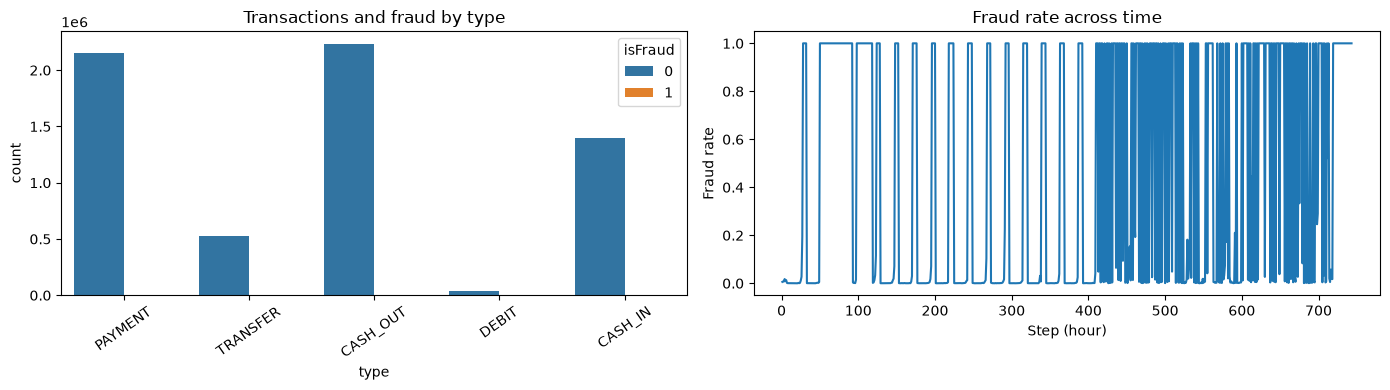

In [3]:
# Data quality, class balance, and basic EDA
quality = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'n_unique': df.nunique()})
display(quality)
print(f'Fraud transactions: {df.isFraud.sum():,} / {len(df):,} ({df.isFraud.mean():.3%})')
print(f'Exact duplicate rows: {df.duplicated().sum():,}; time range: {df.step.min()}–{df.step.max()}')
by_type = df.groupby('type')['isFraud'].agg(transactions='size', frauds='sum', fraud_rate='mean').sort_values('fraud_rate', ascending=False)
display(by_type)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x='type', hue='isFraud', ax=axes[0]); axes[0].tick_params(axis='x', rotation=35); axes[0].set_title('Transactions and fraud by type')
df.groupby('step')['isFraud'].mean().plot(ax=axes[1], title='Fraud rate across time', xlabel='Step (hour)', ylabel='Fraud rate')
plt.tight_layout()


## Leakage check and feature engineering

Only pre-authorisation features may enter a model. Account IDs are high-cardinality identifiers; post-transaction balances are unknown at decision time; and `isFlaggedFraud` is a simulator rule that flags only 16 already-fraudulent records. All are excluded. No target encoding is used, avoiding fold leakage.

In [4]:
TARGET = 'isFraud'
LEAKY_OR_UNAVAILABLE = [TARGET, 'nameOrig', 'nameDest', 'newbalanceOrig', 'newbalanceDest', 'isFlaggedFraud']
def make_features(frame):
    out = frame.drop(columns=LEAKY_OR_UNAVAILABLE, errors='ignore').copy()
    out['hour_of_day'] = out['step'] % 24
    out['day'] = out['step'] // 24
    out['log_amount'] = np.log1p(out['amount'])
    out['origin_balance_zero'] = (out['oldbalanceOrg'] == 0).astype('int8')
    out['destination_balance_zero'] = (out['oldbalanceDest'] == 0).astype('int8')
    out['amount_to_origin_balance'] = out['amount'] / (out['oldbalanceOrg'] + 1)
    return out.replace([np.inf, -np.inf], np.nan)
X, y = make_features(df), df[TARGET].astype('int8')
assert not set(LEAKY_OR_UNAVAILABLE).intersection(X.columns)
display(X.head())


,step,type,amount,oldbalanceOrg,oldbalanceDest,hour_of_day,day,log_amount,origin_balance_zero,destination_balance_zero,amount_to_origin_balance
0,1,PAYMENT,9839.64,170136.0,0.0,1,0,9.194276,0,1,0.057834
1,1,PAYMENT,1864.28,21249.0,0.0,1,0,7.531166,0,1,0.087731
2,1,TRANSFER,181.00,181.0,0.0,1,0,5.204007,0,1,0.994505
3,1,CASH_OUT,181.00,181.0,21182.0,1,0,5.204007,0,0,0.994505
4,1,PAYMENT,11668.14,41554.0,0.0,1,0,9.364703,0,1,0.280788


## Train/test split and preprocessing

The final 20% of time steps is held out. A random split would train on future behavior. For practical local tuning, fit data keeps every fraud and samples only the earlier non-fraud transactions; the test set is never sampled.

In [5]:
cutoff = df['step'].quantile(0.80)
train_mask = df['step'] < cutoff
X_train_full, X_test = X.loc[train_mask], X.loc[~train_mask]
y_train_full, y_test = y.loc[train_mask], y.loc[~train_mask]
MAX_NEGATIVES = 340_000  # Set to None to train on every negative.
pos_idx = y_train_full[y_train_full.eq(1)].index
negatives = y_train_full[y_train_full.eq(0)]
neg_idx = negatives.sample(n=len(negatives) if MAX_NEGATIVES is None else min(MAX_NEGATIVES, len(negatives)), random_state=RANDOM_STATE).index
fit_idx = pos_idx.union(neg_idx)
X_train = X_train_full.loc[fit_idx].sort_values('step')
y_train = y_train_full.loc[X_train.index]
print(f'Fit train: {X_train.shape}; holdout: {X_test.shape}')
print(f'Fit fraud rate: {y_train.mean():.3%}; test fraud rate: {y_test.mean():.3%}')
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
preprocessor = ColumnTransformer([
    ('numeric', SimpleImputer(strategy='median'), numeric_features),
    ('category', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), ['type'])
], verbose_feature_names_out=False)


Fit train: (343955, 11); holdout: (1293523, 11)
Fit fraud rate: 1.150%; test fraud rate: 0.329%


## Baseline → training → time-series CV → hyperparameter tuning

The prevalence-only baseline establishes the minimum. The boosted-tree model uses inverse-frequency weights, while CV keeps validation records later than their corresponding training records.

In [6]:
def evaluate(model, X_eval, y_eval, label):
    scores = model.predict_proba(X_eval)[:, 1]
    print(f'{label} ROC-AUC: {roc_auc_score(y_eval, scores):.4f}')
    print(f'{label} PR-AUC:  {average_precision_score(y_eval, scores):.4f}')
    return scores
baseline = Pipeline([('prep', preprocessor), ('model', DummyClassifier(strategy='prior'))])
baseline.fit(X_train, y_train)
_ = evaluate(baseline, X_test, y_test, 'Prevalence baseline')
fraud_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
weights = np.where(y_train.eq(1), fraud_weight, 1.0)
model = Pipeline([('prep', preprocessor), ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=250))])
search = RandomizedSearchCV(model, {
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1], 'model__max_leaf_nodes': [15, 31, 63],
    'model__l2_regularization': [0.0, 0.1, 1.0], 'model__min_samples_leaf': [20, 50, 100]},
    n_iter=8, scoring='average_precision', cv=TimeSeriesSplit(n_splits=3), n_jobs=-1, verbose=1, random_state=RANDOM_STATE)
search.fit(X_train, y_train, model__sample_weight=weights)
print('Best CV PR-AUC:', round(search.best_score_, 4))
print('Best parameters:', search.best_params_)
best_model = search.best_estimator_


Prevalence baseline ROC-AUC: 0.5000
Prevalence baseline PR-AUC:  0.0033
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV PR-AUC: 0.9988
Best parameters: {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 15, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}


## Evaluation and threshold selection

In a production experiment choose the operating threshold on a validation tail, then apply it once to the holdout. The next cell shows the precision/recall trade-off at a 90% recall target for exploration.

Tuned model ROC-AUC: 1.0000
Tuned model PR-AUC:  0.9998
Threshold for >= 90% recall: 0.9994
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998   1289265
           1     0.9997    0.9028    0.9488      4258

    accuracy                         0.9997   1293523
   macro avg     0.9997    0.9514    0.9743   1293523
weighted avg     0.9997    0.9997    0.9997   1293523



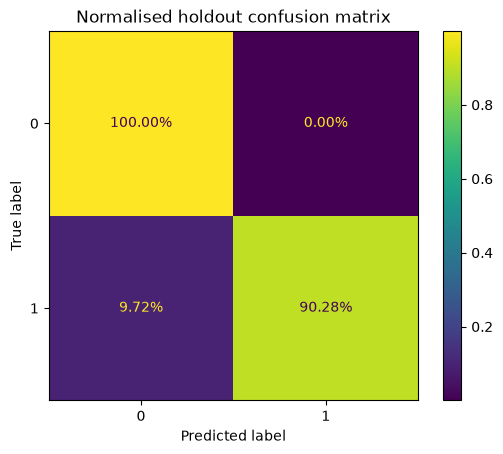

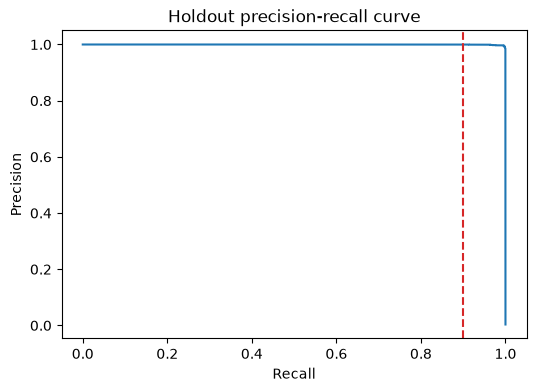

In [7]:
test_scores = evaluate(best_model, X_test, y_test, 'Tuned model')
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)
target_recall = 0.90
eligible = np.flatnonzero(recall[:-1] >= target_recall)
threshold = thresholds[eligible[-1]] if len(eligible) else 0.5
test_pred = (test_scores >= threshold).astype(int)
print(f'Threshold for >= {target_recall:.0%} recall: {threshold:.4f}')
print(classification_report(y_test, test_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, normalize='true', values_format='.2%'); plt.title('Normalised holdout confusion matrix'); plt.show()
plt.figure(figsize=(6, 4)); plt.plot(recall, precision); plt.axvline(target_recall, color='tab:red', ls='--'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Holdout precision-recall curve'); plt.show()


## Conclusions

- There are 8,213 frauds among 6,362,620 transactions (~0.129%); accuracy alone is inappropriate.
- Fraud occurs only in `TRANSFER` and `CASH_OUT` in this simulation—monitor that pattern for drift in real data.
- Set the final threshold against the cost of missed fraud and manual-review capacity.
- Before deployment, validate on a strictly later period and monitor score, feature, and performance drift.